In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [3]:
df=pd.read_csv("C:/Users/con1k/Documents/datascience_course/dataset_proj/realtor-data.zip.csv")

In [4]:
df.shape

(2226382, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          object 
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            object 
 8   state           object 
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  object 
dtypes: float64(8), object(4)
memory usage: 203.8+ MB


In [6]:
df.describe()

,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,2.221849e+06,2.224841e+06,1.745065e+06,1.714611e+06,1.900793e+06,2.215516e+06,2.226083e+06,1.657898e+06
mean,5.293989e+04,5.241955e+05,3.275841e+00,2.496440e+00,1.522303e+01,1.012325e+06,5.218668e+04,2.714471e+03
std,3.064275e+04,2.138893e+06,1.567274e+00,1.652573e+00,7.628238e+02,5.837635e+05,2.895408e+04,8.081635e+05
min,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
25%,2.386100e+04,1.650000e+05,3.000000e+00,2.000000e+00,1.500000e-01,5.063128e+05,2.961700e+04,1.300000e+03
50%,5.288400e+04,3.250000e+05,3.000000e+00,2.000000e+00,2.600000e-01,1.012766e+06,4.838200e+04,1.760000e+03
75%,7.918300e+04,5.500000e+05,4.000000e+00,3.000000e+00,9.800000e-01,1.521173e+06,7.807000e+04,2.413000e+03
max,1.101420e+05,2.147484e+09,4.730000e+02,8.300000e+02,1.000000e+05,2.001357e+06,9.999900e+04,1.040400e+09


In [7]:
df.describe(include=['O'])

,status,city,state,prev_sold_date
count,2226382,2224975,2226374,1492085
unique,3,20098,55,14954
top,for_sale,Houston,Florida,2022-03-31
freq,1389306,23862,249432,17171


In [8]:
df['status'].value_counts()

status
for_sale          1389306
sold               812009
ready_to_build      25067
Name: count, dtype: int64

In [9]:
df.isnull()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,False,False,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
2226377,False,False,False,False,False,False,False,False,False,False,False,False
2226378,False,False,False,False,False,False,False,False,False,False,False,False
2226379,False,False,False,False,False,False,False,False,False,False,False,False
2226380,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

brokered_by         4533
status                 0
price               1541
bed               481317
bath              511771
acre_lot          325589
street             10866
city                1407
state                  8
zip_code             299
house_size        568484
prev_sold_date    734297
dtype: int64

In [11]:
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


In [12]:
df.columns = df.columns.str.strip().str.lower()

In [13]:
cols_to_drop = ['brokered_by', 'street', 'zip_code', 'prev_sold_date']
df=df.drop(columns=cols_to_drop,errors='ignore')
print(f"dropped colums: {cols_to_drop}")

dropped colums: ['brokered_by', 'street', 'zip_code', 'prev_sold_date']


In [14]:
if 'status' in df.columns:
    df=df[df['status']=='for_sale']
    df=df.drop(columns=['status'])
    print(f"filtered 'for sale' properties and dropped 'status' column")

filtered 'for sale' properties and dropped 'status' column


In [15]:
initial_count = len(df)
print(initial_count)

1389306


In [16]:
df = df[(df['price'] > 30000) & (df['price'] < 5000000)]

In [17]:
df = df[(df['house_size'] >= 300) & (df['house_size'] <= 12000)]

In [18]:
df = df[(df['bed'] >= 1) & (df['bed'] <= 10)]

In [19]:
df = df[(df['bath'] >= 1) & (df['bath'] <= 10)]

In [20]:
df= df[df['acre_lot'] <= 20.0]

In [21]:
removed_anomalies = initial_count - len(df)
print(f"Removed {removed_anomalies} anomalous records.")
print(f"Remaining records: {len(df):,}")

Removed 664211 anomalous records.
Remaining records: 725,095


In [22]:
initial_rows = len(df)
duplicates_found = df.duplicated().sum()
print(duplicates_found)

9329


In [23]:
df = df.drop_duplicates()
print(f"duplicates deleted,remainning rows {len(df):,} ")

duplicates deleted,remainning rows 715,766 


In [24]:
df.isnull().sum()

price           0
bed             0
bath            0
acre_lot        0
city          232
state           0
house_size      0
dtype: int64

In [25]:
df.describe().columns

Index(['price', 'bed', 'bath', 'acre_lot', 'house_size'], dtype='object')

In [26]:
numerical=['price', 'bed', 'bath', 'acre_lot', 'house_size']
for i in numerical:
    if df[i].isnull().sum()>0:
        median=df[i].median()
        df[i]=df[i].fillna(median)
        print(f"missing values {i} filled with {median:.2f}")

In [27]:
df.describe(include='O').columns

Index(['city', 'state'], dtype='object')

In [28]:
if 'state' in df.columns and df['state'].isnull().sum() > 0:
    df['state'] = df['state'].fillna(df['state'].mode()[0])

In [29]:
if 'city' in df.columns and df['city'].isnull().sum() > 0:
    df['city'] = df['city'].fillna("Unknown")

In [30]:
df=df.dropna(subset=['price'])

In [31]:
df.isnull().sum()

price         0
bed           0
bath          0
acre_lot      0
city          0
state         0
house_size    0
dtype: int64

In [32]:
len(df)

715766

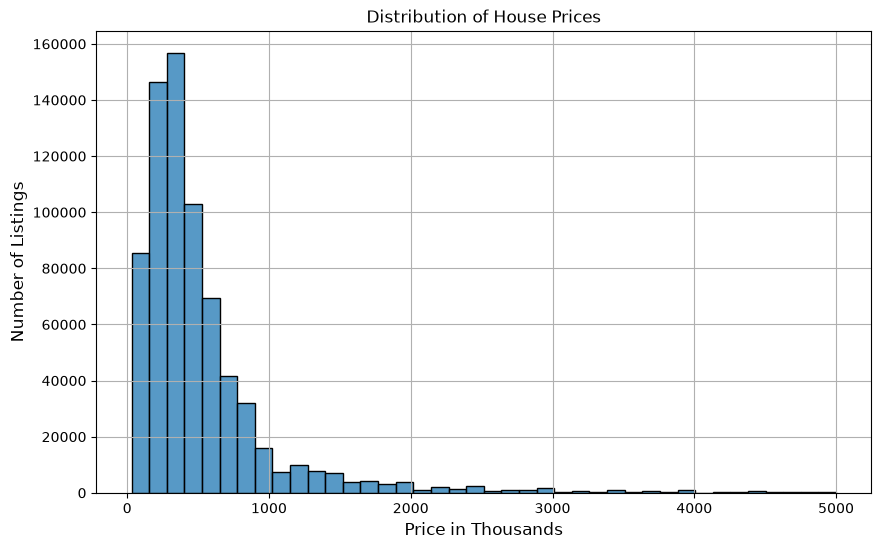

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'] / 1000, bins=40)
plt.title("Distribution of House Prices")
plt.xlabel("Price in Thousands", fontsize=12)
plt.ylabel("Number of Listings", fontsize=12)
plt.grid(True)
plt.show()

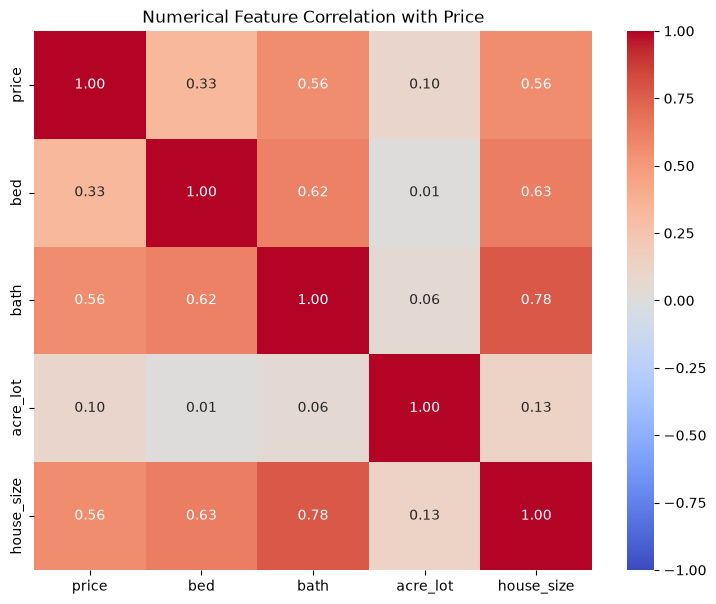

In [34]:
plt.figure(figsize=(9, 7))
num_cols = ['price', 'bed', 'bath', 'acre_lot', 'house_size']
corr_matrix = df[num_cols].corr()
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    vmin=-1, 
    vmax=1,
)
plt.title("Numerical Feature Correlation with Price")
plt.show()

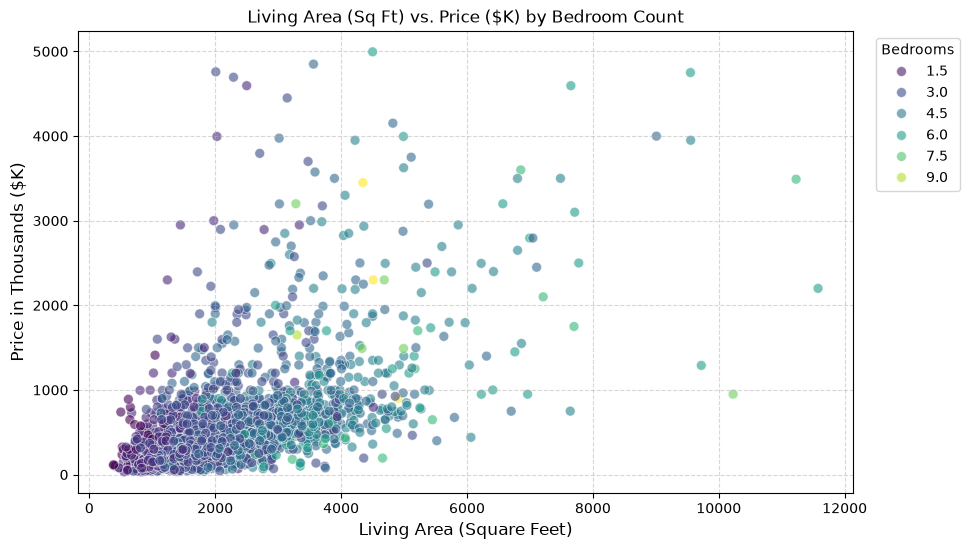

In [35]:
plt.figure(figsize=(10, 6))
sample_data = df.sample(3000, random_state=42)
sns.scatterplot(
    data=sample_data, 
    x='house_size', 
    y=sample_data['price'] / 1000, 
    hue='bed', 
    palette='viridis', 
    alpha=0.6,
    s=50
)
plt.title("Living Area (Sq Ft) vs. Price ($K) by Bedroom Count")
plt.xlabel("Living Area (Square Feet)", fontsize=12)
plt.ylabel("Price in Thousands ($K)", fontsize=12)
plt.legend(title="Bedrooms", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

C:\Users\con1k\AppData\Local\Temp\ipykernel_7772\2829267106.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


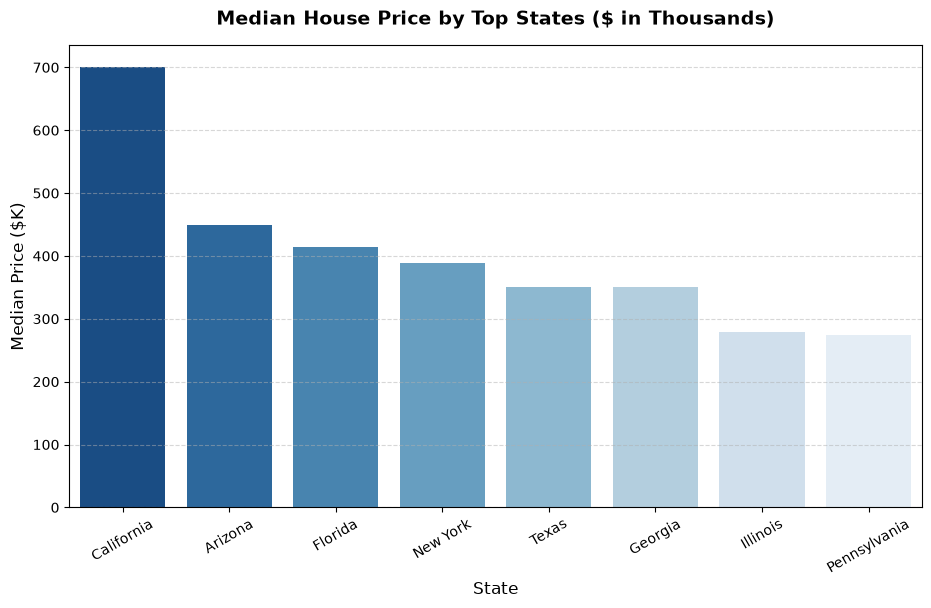

In [36]:
plt.figure(figsize=(11, 6))
top_states = df['state'].value_counts().head(8).index
df_top_states = df[df['state'].isin(top_states)]
state_order = df_top_states.groupby('state')['price'].median().sort_values(ascending=False).index
sns.barplot(
    data=df_top_states, 
    x='state', 
    y=df_top_states['price'] / 1000, 
    order=state_order, 
    estimator=np.median, 
    errorbar=None, 
    palette="Blues_r"
)
plt.title("Median House Price by Top States ($ in Thousands)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("State", fontsize=12)
plt.ylabel("Median Price ($K)", fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [37]:
df_sample = df.sample(n=60000, random_state=42).copy()

In [38]:
top_10_states = df_sample['state'].value_counts().head(10).index.tolist()
df_sample = df_sample[df_sample['state'].isin(top_10_states)]

In [39]:
numeric_features = ['bed', 'bath', 'acre_lot', 'house_size']
categorical_features = ['state']
target_col = 'price'

In [40]:
X = df_sample[numeric_features + categorical_features]
y = df_sample[target_col]

In [41]:
print(f"Features (X) selected: {list(X.columns)}")
print(f"Target (y) selected:   '{target_col}'")
print(f"Dataset shape for modeling: {X.shape[0]:,} rows × {X.shape[1]} columns")

Features (X) selected: ['bed', 'bath', 'acre_lot', 'house_size', 'state']
Target (y) selected:   'price'
Dataset shape for modeling: 32,184 rows × 5 columns


In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)
print("   - StandardScaler applied to: ['bed', 'bath', 'acre_lot', 'house_size']")
print("   - OneHotEncoder applied to:   ['state']")

   - StandardScaler applied to: ['bed', 'bath', 'acre_lot', 'house_size']
   - OneHotEncoder applied to:   ['state']


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42
)

In [44]:
print(f"Training set: {X_train.shape[0]:,} records (80%)")
print(f"Testing set:  {X_test.shape[0]:,} records (20%)")
print(f"Total features in X: {X_train.shape[1]}")

Training set: 25,747 records (80%)
Testing set:  6,437 records (20%)
Total features in X: 5


In [45]:
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [46]:
print("Training Model 1: Linear Regression")
pipeline_lr.fit(X_train, y_train)
print("Linear Regression trained successfully.")

Training Model 1: Linear Regression
Linear Regression trained successfully.


In [47]:
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100, 
        max_depth=16, 
        min_samples_split=6, 
        random_state=42, 
        n_jobs=-1
    ))
])
print("Training Model 2: Random Forest Regressor (Multi-threaded)")
pipeline_rf.fit(X_train, y_train)
print("Random Forest Regressor trained successfully.")


Training Model 2: Random Forest Regressor (Multi-threaded)


Random Forest Regressor trained successfully.


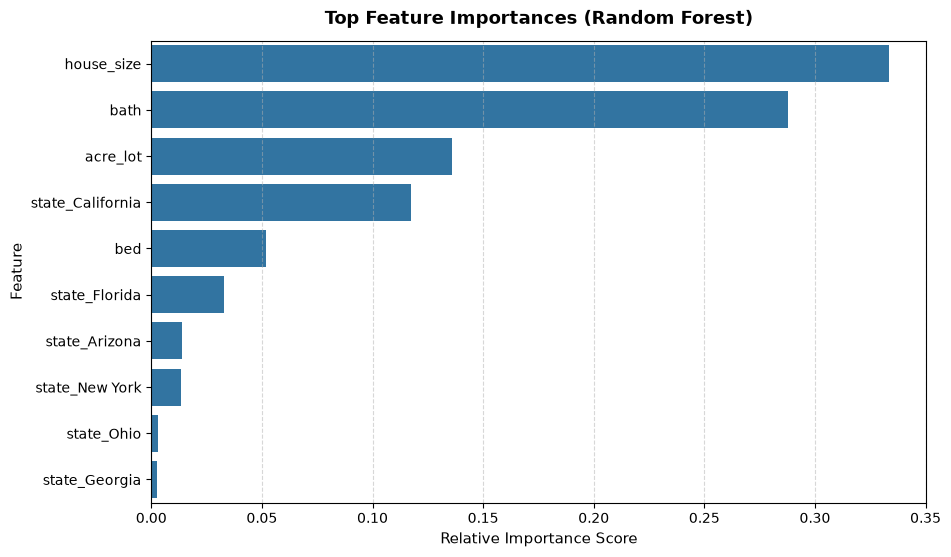

In [48]:
plt.figure(figsize=(10, 6))
ohe_feature_names = list(pipeline_rf.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features))
all_features = numeric_features + ohe_feature_names
importances = pipeline_rf.named_steps['regressor'].feature_importances_
feat_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)
sns.barplot(data=feat_df, x='Importance', y='Feature')
plt.title("Top Feature Importances (Random Forest)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Relative Importance Score", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [49]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    # Predict on training and testing data
    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)
    
    # Calculate evaluation metrics
    metrics = {
        'Train R2': r2_score(y_tr, pred_train),
        'Test R2': r2_score(y_te, pred_test),
        'Test MAE ($)': mean_absolute_error(y_te, pred_test),
        'Test RMSE ($)': np.sqrt(mean_squared_error(y_te, pred_test))
    }
    return metrics, pred_test
metrics_lr, y_pred_lr = evaluate_model(pipeline_lr, X_train, y_train, X_test, y_test)
metrics_rf, y_pred_rf = evaluate_model(pipeline_rf, X_train, y_train, X_test, y_test)
print(metrics_lr)
print(metrics_rf)

{'Train R2': 0.46387206921781654, 'Test R2': 0.4670581765908578, 'Test MAE ($)': 251569.9704615987, 'Test RMSE ($)': np.float64(429207.63728190935)}
{'Train R2': 0.8020101862062985, 'Test R2': 0.5039638523027832, 'Test MAE ($)': 223414.88924467258, 'Test RMSE ($)': np.float64(414079.9502095338)}


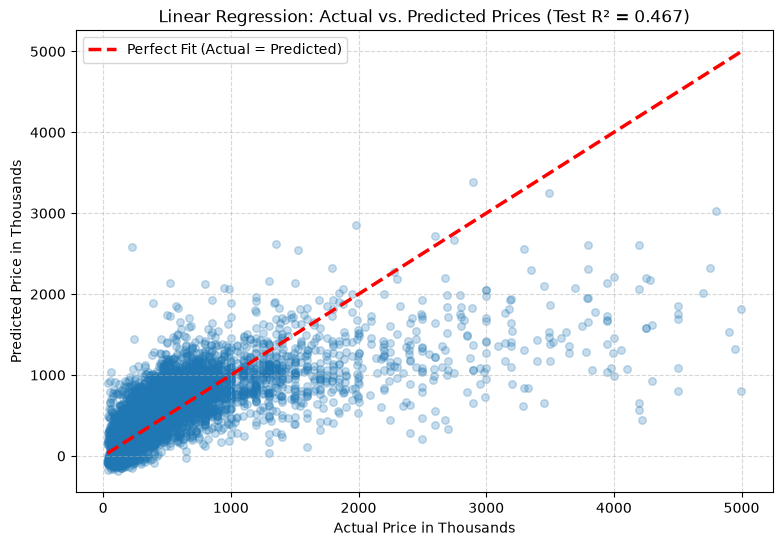

In [50]:
plt.figure(figsize=(9, 6))
plt.scatter(y_test / 1000, y_pred_lr / 1000, alpha=0.25, s=30)
plt.plot(
    [y_test.min() / 1000, y_test.max() / 1000], 
    [y_test.min() / 1000, y_test.max() / 1000], 
    'r--', 
    lw=2.5, 
    label='Perfect Fit (Actual = Predicted)'
)
plt.title(f"Linear Regression: Actual vs. Predicted Prices (Test R² = {metrics_lr['Test R2']:.3f})")
plt.xlabel("Actual Price in Thousands")
plt.ylabel("Predicted Price in Thousands")
plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

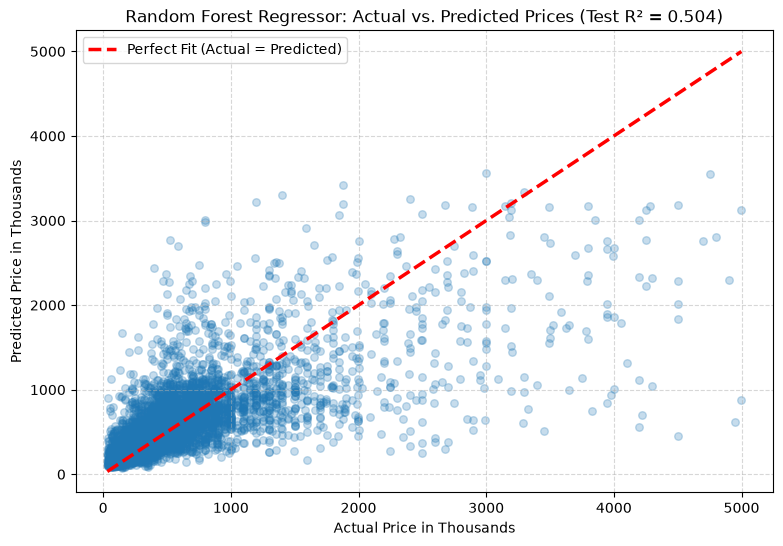

In [51]:
plt.figure(figsize=(9, 6))
plt.scatter(y_test / 1000, y_pred_rf / 1000, alpha=0.25, s=30)
plt.plot(
    [y_test.min() / 1000, y_test.max() / 1000], 
    [y_test.min() / 1000, y_test.max() / 1000], 
    'r--', 
    lw=2.5, 
    label='Perfect Fit (Actual = Predicted)'
)
plt.title(f"Random Forest Regressor: Actual vs. Predicted Prices (Test R² = {metrics_rf['Test R2']:.3f})")
plt.xlabel("Actual Price in Thousands")
plt.ylabel("Predicted Price in Thousands")
plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [52]:
comparison_table = pd.DataFrame(
    [metrics_lr, metrics_rf], 
    index=['Model 1: Linear Regression', 'Model 2: Random Forest Regressor']
)
print("--- MODEL EVALUATION SUMMARY TABLE ---")
display(
    comparison_table.style
    .highlight_max(subset=['Train R2', 'Test R2'])
    .highlight_min(subset=['Test MAE ($)', 'Test RMSE ($)'])
    .format({'Train R2': '{:.4f}', 'Test R2': '{:.4f}', 'Test MAE ($)': '${:,.2f}', 'Test RMSE ($)': '${:,.2f}'})
)

--- MODEL EVALUATION SUMMARY TABLE ---


,Train R2,Test R2,Test MAE ($),Test RMSE ($)
Model 1: Linear Regression,0.4639,0.4671,"$251,569.97","$429,207.64"
Model 2: Random Forest Regressor,0.8020,0.5040,"$223,414.89","$414,079.95"


In [53]:
best_model = pipeline_rf if metrics_rf['Test R2'] > metrics_lr['Test R2'] else pipeline_lr
winner_name = "Random Forest Regressor" if best_model == pipeline_rf else "Linear Regression"

In [54]:

print(f"Final Selected Model: {winner_name}")
print(f"Reason: {winner_name} achieved higher Test R² ({max(metrics_rf['Test R2'], metrics_lr['Test R2']):.4f}) "
      f"and reduced average error (MAE) by ~${abs(metrics_rf['Test MAE ($)'] - metrics_lr['Test MAE ($)']):,.2f}.")


Final Selected Model: Random Forest Regressor
Reason: Random Forest Regressor achieved higher Test R² (0.5040) and reduced average error (MAE) by ~$28,155.08.


In [55]:
sample_properties = pd.DataFrame([
    {'bed': 3, 'bath': 2.0, 'acre_lot': 0.25, 'house_size': 1850, 'state': 'Massachusetts'},
    {'bed': 4, 'bath': 3.5, 'acre_lot': 0.80, 'house_size': 3200, 'state': 'New Jersey'},
    {'bed': 2, 'bath': 1.0, 'acre_lot': 0.12, 'house_size': 950, 'state': 'Connecticut'}
])
sample_predictions = best_model.predict(sample_properties)
print("--- INFERENCE DEMO ON UNSEEN HOUSES ---")
for i, pred in enumerate(sample_predictions):
    p = sample_properties.iloc[i]
    print(f"Listing {i+1} [{p['state']}]: {p['bed']} Bed | {p['bath']} Bath | {p['house_size']} sqft | {p['acre_lot']} acres")
    print(f"  ==> Predicted Market Valuation: ${pred:,.2f}\n")

--- INFERENCE DEMO ON UNSEEN HOUSES ---
Listing 1 [Massachusetts]: 3 Bed | 2.0 Bath | 1850 sqft | 0.25 acres
  ==> Predicted Market Valuation: $301,915.18

Listing 2 [New Jersey]: 4 Bed | 3.5 Bath | 3200 sqft | 0.8 acres
  ==> Predicted Market Valuation: $629,392.53

Listing 3 [Connecticut]: 2 Bed | 1.0 Bath | 950 sqft | 0.12 acres
  ==> Predicted Market Valuation: $145,955.41



In [56]:
os.makedirs("saved_models", exist_ok=True)
EXPORT_PATH = "saved_models/house_price_pipeline.pkl"

In [57]:
joblib.dump(best_model, EXPORT_PATH)
print(f"Pipeline exported successfully to: '{EXPORT_PATH}'")

Pipeline exported successfully to: 'saved_models/house_price_pipeline.pkl'


In [58]:
reloaded_pipeline = joblib.load(EXPORT_PATH)
test_pred = reloaded_pipeline.predict(sample_properties.iloc[[0]])[0]
print(f"Reload test passed. Verified prediction: ${test_pred:,.2f}")

Reload test passed. Verified prediction: $301,915.18
